In [ ]:
import torch
import os

# from utils import load_model, load_data
from dataset.data_loader_evo import load_data
from utils.config_loader import get_config
from dataset.data_loader_gen import get_gen_dataloader

config = get_config()

root_dir = "/data00/XXX/data"

data_id = "MMMU/MMMU_Pro"
local_data_dir = root_dir + "/datasets/mmmu_pro"
# print(config)
# local_data_dir = root_dir + "/datasets/mmmu_pro"
# data_id = "Lin-Chen/MMStar"
# local_data_dir =  "/data00/XXX/data/datasets/mmstar"

# data_id = "MathLLMs/MathVision"
# local_data_dir = "/data00/XXX/data/datasets/mathvision"
# data_id = "craigwu/vstar_bench"
# local_data_dir = "/data00/XXX/data/datasets/vstar_bench"

# processor, model = load_model(model_id, local_model_dir)

# ds = load_data(data_id, local_data_dir, config) 

ds = load_data(data_id, local_data_dir, config)
# test_loader, test_ds, test_ids, stage_pool = get_gen_dataloader(ds, config, test=True)



In [ ]:
from utils.draw_bboxes import draw_bboxes

# sample = ds["train"][4152]
# pred_bbox = [[75, 0, 360, 1023]]
# sample = ds[99]
# idx = 2576
# idx = 2227
# print(test_ids[51])
# sample = ds[test_ids[idx]]
# q = "Circles $\\omega_1$, $\\omega_2$, and $\\omega_3$ each have radius $4$"

q = "<image 1>Which structure in this picture is responsible for synthesizing proteins"
# sample_id = 1393
for idx, sample in enumerate(ds):
    if q in sample['question'] :
        print(f"Idx in the ds: {idx}")
        print(f"Sample Id: {sample['id']}")
        break

sample = ds[idx]

print(sample['question'])
print(sample['options'])
print(sample['answer'])
sample["image"] = sample["image_1"]
out_img = draw_bboxes(sample, width=3, fill_alpha=0.25)

# out_img.save(f"Mathvision_sample_{idx}.jpg")
# out_img.save(f"vstar_sample_{idx}.jpg")
out_img.save("mmmu-pro-sample.jpg")


In [ ]:
sample["image"] = sample["image_1"]
out_img = draw_bboxes(sample, width=3, fill_alpha=0.25)

# out_img.save(f"Mathvision_sample_{idx}.jpg")
# out_img.save(f"vstar_sample_{idx}.jpg")
out_img.save("mmmu-pro-sample.jpg")

In [ ]:
import pickle


sample_id = sample['id']
# search_space_path = config["search_space_dir"]['']
stage_outputs_dir = "/data00/XXX/stage_output"
stage_output_path = os.path.join(stage_outputs_dir, data_id.split("/")[-1], f"stage_outputs_{sample_id}.pkl")

with open(stage_output_path, "rb") as f:
    print(f"Loading stage outputs from {stage_output_path}")
    stage_outputs = pickle.load(f)

# cot_0 = "TASK.INTERPRETATION,VISUAL.OBSERVATION,TEXTUAL.UNDERSTANDING,CONTEXTUAL.LINKING,FACT.EXTRACTION,VARIABLE.DEFINITION,RELATIONAL.REASONING,QUANTITATIVE.REASONING,LOGICAL.FILTERING,HYPOTHESIS.GENERATION,CROSSMODAL.ALIGNMENT,SELFCONSISTENCY.CHECK,COMPARATIVE.EVALUATION,EXPLANATION.GENERATION"
# cot_1 = "LOGICAL.FILTERING,VISUAL.OBSERVATION"
# cot_2 = "LOGICAL.FILTERING"

# cot_0 = "VISUAL.OBSERVATION,SELFCONSISTENCY.CHECK,TEXTUAL.UNDERSTANDING"
# cot_1 = "TASK.INTERPRETATION"

# cot_0 = "RELATIONAL.REASONING,FACT.EXTRACTION,TASK.INTERPRETATION"
cot_1 = "VISUAL.OBSERVATION,LOGICAL.FILTERING"
cot_0 = "VISUAL.OBSERVATION"


out_0 = stage_outputs[cot_0]
out_1 = stage_outputs[cot_1]
print(out_0.keys())


In [ ]:
print(out_0["direct_answer_raw"])
print(out_0['answer_raw'])

In [ ]:
import json


json_str = json.dumps(out_0['importance_dict'], indent=4)
print(json_str)

print(out_0["answer_raw"])
print(out_0["blackboard_text"])


In [ ]:
print(out_0["A"])
print(out_0["a_to_final"])

In [ ]:
json_str = json.dumps(out_1['importance_dict'], indent=4)
print(json_str)

print(out_1["answer_raw"])
print(out_1["blackboard_text"])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.patches import RegularPolygon
from matplotlib.path import Path
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

# ---------- Polygon radar (hexagon) projection ----------
def radar_factory(num_vars, frame='polygon'):
    """Create a radar projection with either a circle or polygon frame."""
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):
        name = 'radar'
        def _gen_axes_patch(self):
            if frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars, radius=.5, edgecolor='none')
            return super()._gen_axes_patch()

        def _gen_axes_spines(self):
            if frame == 'polygon':
                spine = Spine(self, 'circle', Path.unit_regular_polygon(num_vars))
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5) + self.transAxes)
                return {'polar': spine}
            return super()._gen_axes_spines()

    register_projection(RadarAxes)
    return theta

# Axes order (match table columns)
axes_labels = ["MMMU-Pro (10)", "MMMU-Pro (4)", "VStar", "MMStar", "MathVision", "MathVerse"]

# === Table values (percent) ===
scores = {
    "Qwen3 VL 4B":                   [32.42, 45.78, 79.14, 58.95, 22.59, 25.25],
    "Qwen3 VL 4B+ CoT":              [37.57, 49.02, 76.47, 67.85, 29.75, 36.17],
    "Qwen3 VL 4B+ VReST":            [46.30, 56.13, 83.42, 49.27, 44.67, 47.97],
    "Qwen3 VL 4B+ ReaGEN":           [52.54, 64.51, 84.49, 75.77, 44.60, 47.59],  # highlight
    "InternVL3.5-4B":                [29.77, 41.45, 67.91, 61.00, 23.22, 24.62],
    "Qwen3-VL-8B":                   [38.55, 48.67, 81.23, 61.17, 25.03, 29.82],
    "GPT-4o":                        [54.00, 64.70, 66.00, 64.70, 30.60, 21.57],
}

legend_order = [
    "Qwen3 VL 4B","Qwen3 VL 4B+ CoT","Qwen3 VL 4B+ VReST","Qwen3 VL 4B+ ReaGEN",
    "InternVL3.5-4B","Qwen3-VL-8B","GPT-4o",
]

# IMPORTANT: match the key exactly
highlight_method = "Qwen3 VL 4B+ ReaGEN"

def closed(vals): 
    return list(vals) + [vals[0]]

N = len(axes_labels)
thetas = radar_factory(N, frame='polygon')  # hexagon frame

# ---- Figure ----
fig = plt.figure(figsize=(9.6, 8.2))
ax = fig.add_subplot(111, projection='radar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(thetas), axes_labels)

# radial limits
all_vals = np.concatenate([np.array(v, dtype=float) for v in scores.values()])
finite = all_vals[np.isfinite(all_vals)]
rmin = max(0, np.floor(finite.min()/10)*10)
rmax = np.ceil(finite.max()/10)*10
ax.set_ylim(rmin, rmax)
ax.set_rlabel_position(0)

# --- Use polygon grid rings (hexagons) ---
ax.yaxis.grid(False)
yticks = [t for t in ax.get_yticks() if rmin < t < rmax]
for t in yticks:
    frac = (t - rmin) / (rmax - rmin)
    hex_ring = RegularPolygon(
        (0.5, 0.5), N, radius=0.5 * frac,
        transform=ax.transAxes, fill=False,
        edgecolor='0.6', linewidth=1.0, linestyle='--'
    )
    ax.add_patch(hex_ring)

ax.xaxis.grid(True, linestyle="--", linewidth=1.0, alpha=0.75)

# plot lines — color palette
tab10 = plt.get_cmap("tab10").colors
palette = {name: tab10[i % len(tab10)] for i, name in enumerate(legend_order)}

highlight_color = "red" 

# --- DRAW TRACES (bold + shaded for ReaGEN) ---
for m in legend_order:
    if m not in scores:
        continue
    vals = closed(scores[m])
    theta_closed = np.append(thetas, thetas[0])
    if m == highlight_method:
        # bold line
        ax.plot(theta_closed, vals, color=highlight_color,
                linewidth=3.2, marker='o', markersize=6, alpha=1.0, label=m, zorder=3)
        # slight shading (no outline color change)
        ax.fill(theta_closed, vals, color=highlight_color, alpha=0.12, zorder=1)
    else:
        ax.plot(theta_closed, vals, color=palette[m],
                linewidth=1.8, marker='o', markersize=4, alpha=0.98, label=m, zorder=2)

# Bold in-figure text (not legend)
for lbl in ax.get_xticklabels(): lbl.set_fontweight('bold')
for lbl in ax.get_yticklabels(): lbl.set_fontweight('bold')
ax.tick_params(axis='x', pad=14)
ax.tick_params(axis='y', pad=6)
ax.tick_params(labelsize=11)

# Legend top-right outside
# plt.subplots_adjust(right=0.78)
plt.subplots_adjust(left=0.14, right=0.90)
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper left",
#            frameon=False, ncol=1, handlelength=2, columnspacing=1.0)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(0.15, 1.0),   # ← increase the first number to move right (e.g., 0.18, 0.20,…)
    frameon=False,
    ncol=1,
    handlelength=2.8,
    columnspacing=1.0,
    fontsize=12.5
)

fig.savefig("radar_hexagon.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
import torch
# from config import get_config
from utils.config_loader import get_config
from model.model_loader_gen import GENModel_1

def count_params(model, trainable_only=False):
    params = (p for p in model.parameters() if (p.requires_grad or not trainable_only))
    total = sum(p.numel() for p in params)
    return total

def model_size_bytes(model):
    # Use first parameter’s dtype as an estimate (mixed dtypes? sums exactly)
    total_bytes = 0
    for p in model.parameters():
        total_bytes += p.numel() * torch.finfo(p.dtype).bits // 8 if p.is_floating_point() else p.numel() * p.element_size()
    return total_bytes

def pretty(n):
    for unit in ["", "K", "M", "B"]:
        if abs(n) < 1000:
            return f"{n:.3g}{unit}"
        n /= 1000
    return f"{n:.3g}T"

def pretty_bytes(n):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PB"

# Example:
# model = ...
config = get_config()
stage_pool = config['inference']["stages_pool"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GENModel_1(emb_dim=2560, 
                                num_stages=len(stage_pool), 
                                max_cot_len=8, device=device, config=config)

total_params = count_params(model, trainable_only=False)
trainable_params = count_params(model, trainable_only=True)
size_bytes = model_size_bytes(model)

print(f"Total params:      {total_params:,} ({pretty(total_params)})")
print(f"Trainable params:  {trainable_params:,} ({pretty(trainable_params)})")
print(f"Param memory (est): {pretty_bytes(size_bytes)}")


Total params:      18,268,070 (18.3M)
Trainable params:  18,268,070 (18.3M)
Param memory (est): 69.69 MB


In [1]:
import os
import pickle
from tqdm import tqdm

from prompts.stage_n.search_space import flatten_search_space

datasets = ["MathVision", "MathVerse", "MMMU", "MMStar"]

TOPK = 10
REWARD_MIN = 0.5

SAVE_DIR = "./figs_stage_util_and_diversity"
os.makedirs(SAVE_DIR, exist_ok=True)

search_space_dir = "/data00/XXX/searchspace"


def load_topk_chains_for_dataset(ds_path, topk=TOPK, reward_min=REWARD_MIN):
    chains = []
    files = os.listdir(ds_path)
    for file in tqdm(files, total=len(files), desc=f"Processing {os.path.basename(ds_path)}"):
        fpath = os.path.join(ds_path, file)
        if not os.path.isfile(fpath): 
            continue
        try:
            with open(fpath, "rb") as f:
                search_space = pickle.load(f)
        except Exception as e:
            print(f"[WARN] Skip {fpath}: {e}")
            continue

        # You said you have: flatten_search_space(search_space.root) -> list[dict]
        # If it's already in your env, import; else define a fallback:
        if hasattr(search_space, "root"):
            root = search_space.root
        else:
            root = search_space  # fallback

        if 'flatten_search_space' in globals():
            all_chains = flatten_search_space(root)
        else:
            # Minimal fallback: assume search_space is already a list of chains
            all_chains = root if isinstance(root, list) else []

        # take top-k by reward
        sel = sorted(all_chains, key=lambda x: x.get('reward', 0.0), reverse=True)[:topk]
        sel = [c for c in sel if c.get('reward', 0.0) >= reward_min]
        for c in sel:
            # normalize to tuple for hashing
            seq = tuple(c.get('stage_seq', []))
            chains.append({
                "stage_seq": seq,
                "reward": float(c.get('reward', 0.0)),
                "score": float(c.get('score', 0.0)),
                "file": file,
            })
    return chains

def collect_all_chains(search_space_dir, datasets):
    all_chains = []
    per_ds = {}
    for ds in datasets:
        ds_path = os.path.join(search_space_dir, ds)
        if not os.path.isdir(ds_path):
            print(f"[WARN] Missing dataset dir: {ds_path}")
            continue
        chains = load_topk_chains_for_dataset(ds_path)
        per_ds[ds] = chains
        all_chains.extend([(ds, c) for c in chains])
    return per_ds, all_chains


chains_ds, total_chains = collect_all_chains(search_space_dir, datasets)

Processing MMStar: 100%|██████████| 1491/1491 [00:00<00:00, 1742.83it/s]


In [ ]:
import collections
import math
from multiprocessing.context import ForkContext
import numpy as np
from matplotlib import pyplot as plt
import os, pickle, math, collections, itertools

def stage_utilization_stats(chains):
    # chains: list of dicts with "stage_seq" (tuple)
    stage_counts = collections.Counter()
    position_counts = collections.Counter()  # (position_index, stage) -> count
    max_len = 0
    for c in chains:
        seq = c["stage_seq"]

        seq_short = []
        for stage in seq:
            stage_short_name = stage.split(".")[0][0] + stage.split(".")[1][0]
            seq_short.append(stage_short_name)

        seq = seq_short
        max_len = max(max_len, len(seq))
        stage_counts.update(seq)
        for i, s in enumerate(seq):
            position_counts[(i, s)] += 1
    stages = sorted(stage_counts.keys())
    return stages, stage_counts, position_counts, max_len

# -----------------------------
# Plotters (pure matplotlib)
# -----------------------------
def plot_stage_utilization_overall(stages, stage_counts, savepath):
    xs = np.arange(len(stages))
    ys = [stage_counts[s] for s in stages]
    plt.figure(figsize=(10, 3.5))
    plt.bar(xs, ys)
    plt.xticks(xs, stages, fontsize=16)
    plt.xlabel("Stage Names", fontsize=16)
    plt.ylabel("Frequency", fontsize=16)
    # plt.title("Stage Utilization")
    plt.tight_layout()
    plt.savefig(savepath, dpi=200)
    plt.close()

def plot_stage_position_heatmap(stages, position_counts, max_len, savepath):
    # build matrix: rows=position (0..max_len-1), cols=stages
    mat = np.zeros((max_len, len(stages)), dtype=float)
    stage2idx = {s:i for i,s in enumerate(stages)}
    for (pos, stage), cnt in position_counts.items():
        if pos < max_len and stage in stage2idx:
            mat[pos, stage2idx[stage]] = cnt

    # normalize rows to compare positional preferences
    row_sums = mat.sum(axis=1, keepdims=True) + 1e-9
    norm_mat = mat / row_sums

    plt.figure(figsize=(max(8, 0.5 * len(stages)), 0.6 * max_len + 2))
    plt.imshow(norm_mat, aspect='auto', interpolation='nearest')
    plt.colorbar(label="Row-normalized frequency")
    plt.yticks(np.arange(max_len), [f"Pos {i+1}" for i in range(max_len)])
    plt.xticks(np.arange(len(stages)), stages, rotation=45, ha='right')
    plt.title("Stage Position Preferences (row-normalized)")
    plt.tight_layout()
    plt.savefig(savepath, dpi=200)
    plt.close()


combined_chains = [c for _, c in total_chains]
stages, stage_counts, position_counts, max_len = stage_utilization_stats(combined_chains)
plot_stage_utilization_overall(stages, stage_counts, os.path.join(SAVE_DIR, f"util_overall.png"))
plot_stage_position_heatmap(stages, position_counts, 7, os.path.join(SAVE_DIR, f"pos_heatmap.png"))


# ds_name = "MMMU"
# ds_name = "MathVerse"
# ds_name = "MathVision"

# stages, stage_counts, position_counts, max_len = stage_utilization_stats(chains_ds[ds_name])
# plot_stage_utilization_overall(stages, stage_counts, os.path.join(SAVE_DIR, f"{ds_name}_util_overall.png"))
# plot_stage_position_heatmap(stages, position_counts, 7, os.path.join(SAVE_DIR, f"{ds_name}_pos_heatmap.png"))


In [22]:

def diversity_stats(chains):
    # frequency of unique sequences; normalized entropy
    seq_counter = collections.Counter([c["stage_seq"] for c in chains])
    total = sum(seq_counter.values())
    if total == 0:
        return seq_counter, 0.0, 0, 0
    probs = np.array([cnt/total for cnt in seq_counter.values()])
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    max_entropy = math.log(len(seq_counter)) if len(seq_counter) > 0 else 1.0
    norm_entropy = (entropy / max_entropy) if max_entropy > 0 else 0.0
    return seq_counter, norm_entropy, total, len(seq_counter)


def plot_chain_diversity(seq_counter, norm_entropy, total, n_unique, savepath, topN=20):
    # bar chart of top-N most frequent chains
    most_common = seq_counter.most_common(topN)
    labels = [ "→".join(seq) if seq else "(empty)" for seq,_ in most_common ]
    counts = [ cnt for _,cnt in most_common ]

    plt.figure(figsize=(10, max(3.5, 0.35 * len(most_common))))
    y = np.arange(len(most_common))
    plt.barh(y, counts)
    plt.gca().invert_yaxis()
    plt.xlabel("Count")
    plt.title(f"Chain Diversity: unique={n_unique}, entropy={norm_entropy:.3f} (norm), total={total}")
    plt.tight_layout()
    plt.savefig(savepath, dpi=200)
    plt.close()

combined_chains = [c for _, c in total_chains]
seq_counter, nomr_H, total, nuniq = diversity_stats(combined_chains)
plot_chain_diversity(seq_counter, norm_H, total, nuniq, os.path.join(SAVE_DIR, "chain_diversity_overall.png"))

    

In [ ]:
import os, math, collections, itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.cm import get_cmap

# ============ Config ============
SAVE_DIR = "./figs_stage_pca"
os.makedirs(SAVE_DIR, exist_ok=True)

ENCODE_MODE = "bag"   # "positional_onehot" | "bag" | "bigram"
LABEL_TOP = 10                      # annotate top-N most frequent sequences
POINT_ALPHA = 0.8

def build_vocab_and_maxlen(chains):
    """Build stage vocab and find max chain length."""
    stage_counter = collections.Counter()
    max_len = 0
    for c in chains:
        seq = c["stage_seq"]
        stage_counter.update(seq)
        max_len = max(max_len, len(seq))
    stages = sorted(stage_counter.keys())
    return stages, max_len


def encode_positional_onehot(seq, stages, max_len, eos_token="__EOS__"):
    """
    Position-aware one-hot over (stage ∪ {EOS}) for each position; concat across positions.
    Dim = max_len * (len(stages)+1).
    """
    full_vocab = stages + [eos_token]
    s2i = {s: i for i, s in enumerate(full_vocab)}
    V = len(full_vocab)
    vec = np.zeros(max_len * V, dtype=np.float32)
    # fill sequence then eos padding
    padded = list(seq)[:max_len]
    padded += [eos_token] * max(0, max_len - len(padded))
    for pos, s in enumerate(padded):
        idx = pos * V + s2i[s]
        vec[idx] = 1.0
    return vec

def encode_bag(seq, stages):
    """Orderless histogram of stages. Dim = len(stages)."""
    s2i = {s: i for i, s in enumerate(stages)}
    vec = np.zeros(len(stages), dtype=np.float32)
    for s in seq:
        if s in s2i: vec[s2i[s]] += 1.0
    # L2 normalize bag to reduce length bias (optional but helpful)
    nrm = np.linalg.norm(vec) + 1e-8
    return vec / nrm

def encode_bigram(seq, stages, eos_token="__EOS__"):
    """
    Bigram transition counts including EOS. Dim = (V x V) flattened.
    V = len(stages)+1 (EOS).
    """
    full_vocab = stages + [eos_token]
    s2i = {s: i for i, s in enumerate(full_vocab)}
    V = len(full_vocab)
    M = np.zeros((V, V), dtype=np.float32)
    if len(seq) == 0:
        return M.flatten()
    # transitions within seq
    for a, b in zip(seq[:-1], seq[1:]):
        if a in s2i and b in s2i:
            M[s2i[a], s2i[b]] += 1.0
    # final transition to EOS
    last = seq[-1] if len(seq) > 0 else eos_token
    if last in s2i:
        M[s2i[last], s2i[eos_token]] += 1.0
    # row-normalize (conditional probs P(next|curr)) for stability
    row_sums = M.sum(axis=1, keepdims=True) + 1e-8
    M = M / row_sums
    return M.flatten()

def encode_chain(seq, stages, max_len, mode):
    if mode == "positional_onehot":
        return encode_positional_onehot(seq, stages, max_len)
    elif mode == "bag":
        return encode_bag(seq, stages)
    elif mode == "bigram":
        return encode_bigram(seq, stages)
    else:
        raise ValueError(f"Unknown ENCODE_MODE: {mode}")

def pca_2d(X, n_components=2):
    """Try sklearn PCA; fallback to NumPy SVD PCA."""
    try:
        from sklearn.decomposition import PCA
        return PCA(n_components=n_components).fit_transform(X)
    except Exception:
        # center
        Xc = X - X.mean(axis=0, keepdims=True)
        # SVD
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        Z = Xc @ Vt[:n_components].T
        return Z

def prepare_pca_data(per_ds):
    """
    Flattens per_ds into arrays for PCA:
    - X: encoded feature matrix
    - y_ds: dataset names per point
    - rewards: reward per point (for sizing)
    - seqs: original sequences
    - freq: frequency map for annotation
    - stages, max_len: for reference
    """
    # flatten
    flat = []
    for ds, chains in per_ds.items():
    # for ds in datasets 
        for c in chains:
            flat.append((ds, c))

    if not flat:
        return None

    all_chains = [c for (_, c) in flat]
    stages, max_len = build_vocab_and_maxlen(all_chains)

    # frequency of exact sequences (for labels)
    seq_counter = collections.Counter([tuple(c["stage_seq"]) for c in all_chains])

    # encode
    feats, y_ds, rewards, seqs = [], [], [], []
    for ds, c in flat:
        seq = c["stage_seq"]
        v = encode_chain(seq, stages, max_len, ENCODE_MODE)
        feats.append(v)
        y_ds.append(ds)
        rewards.append(float(c.get("reward", 0.0)))
        seqs.append(seq)

    X = np.stack(feats, axis=0)
    rewards = np.array(rewards, dtype=np.float32)
    return {
        "X": X,
        "y_ds": np.array(y_ds),
        "rewards": rewards,
        "seqs": seqs,
        "seq_counter": seq_counter,
        "stages": stages,
        "max_len": max_len
    }

MARKERS = ['o','s','^','D','P','X','v','*','>','<']
# COLORS = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan']
def scatter_pca(
    Z, y_ds, rewards, seqs, seq_counter,
    savepath=None,
    title=None,
    # ---- new width controls ----
    width_in=8.0,           # figure width in inches
    height_in=4.8,          # figure height in inches
    dpi=120,                # dots per inch
    width_px=None           # if set, overrides width_in via width_in = width_px / dpi
):
    """
    Z          : np.ndarray of shape [N, 2] after PCA (x,y)
    y_ds       : iterable of dataset labels for color/grouping
    rewards    : iterable of numeric rewards (used for alpha/size if desired)
    seqs       : iterable of stage sequences (strings) for hover/tooltip if desired
    seq_counter: Counter or dict for counts per unique sequence (can drive size)
    savepath   : where to save the figure (PNG, PDF, etc.)
    title      : plot title

    width_in/height_in/dpi  : control figure physical size
    width_px                : exact pixel width (overrides width_in)
    """


    if width_px is not None:
        width_in = float(width_px) / float(dpi)

    # Basic grouping by dataset label
    groups = defaultdict(list)
    for i, g in enumerate(y_ds):
        groups[g].append(i)

    # Build figure with requested width
    fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi, constrained_layout=True)

    # Choose a colormap for groups
    cmap = get_cmap("tab20")
    all_keys = list(groups.keys())
    all_keys.sort()

    # Optional sizing by frequency (seq_counter)
    def size_for_idx(i, base=12.0, boost=10.0):
        key = seqs[i]
        freq = seq_counter.get(key, 1)
        return base + boost * np.log1p(freq)

    # Optional alpha by reward
    def alpha_for_idx(i, lo=0.25, hi=0.9):
        if rewards is None:
            return 0.7
        r = float(rewards[i])
        r = max(0.0, min(1.0, r))
        return lo + (hi - lo) * r

    # Plot per group
    # for gi, g in enumerate(all_keys):
    datasets = ["MathVision", "MathVerse", "MMMU", "MMStar"]
    for gi, g in enumerate(datasets):
        idxs = groups[g]
        X = Z[idxs, 0]
        Y = Z[idxs, 1]
        # sizes = [size_for_idx(i) for i in idxs]
        sizes = [8 for i in idxs]
        alphas = [alpha_for_idx(i) for i in idxs]
        # color = COLORS[gi % len(COLORS)]
        marker = MARKERS[gi % len(MARKERS)]

        ax.scatter(
            X, Y,
            # c=[color],
            marker=marker,
            alpha=np.mean(alphas) if len(alphas) else 0.7,
            edgecolors="none",
            label=str(g),
            s=sizes
        )

    # ax.set_xlabel("PCA-1")
    # ax.set_ylabel("PCA-2")s
    if title:
        ax.set_title(title, pad=6)
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc="best", fontsize=14, frameon=True)

    if savepath:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    return savepath


# ============ Run (overall and per-dataset) ============
def run_stage_pca(per_ds, save_dir=SAVE_DIR, encode_mode=ENCODE_MODE):
    data = prepare_pca_data(per_ds)
    if data is None:
        print("[PCA] No data found.")
        return

    X = data["X"]
    y_ds = data["y_ds"]
    rewards = data["rewards"]
    seqs = data["seqs"]
    seq_counter = data["seq_counter"]

    Z = pca_2d(X, n_components=2)
    scatter_pca(
        Z, y_ds, rewards, seqs, seq_counter,
        savepath=os.path.join(save_dir, f"cot_pca_overall_{encode_mode}.png"),
        # title=f"Visualization of Searched CoTs"
    )

    print(f"[PCA] Saved overall PCA to {os.path.join(save_dir, f'cot_pca_overall_{encode_mode}.png')}")

    # # Optional: per-dataset PCA (uses only that dataset's chains)
    # for ds, chains in per_ds.items():
    #     if not chains:
    #         continue
    #     sub_per_ds = {ds: chains}
    #     sub_data = prepare_pca_data(sub_per_ds)
    #     if sub_data is None or sub_data["X"].shape[0] < 3:
    #         continue
    #     Z_sub = pca_2d(sub_data["X"], n_components=2)
    #     scatter_pca(
    #         Z_sub, sub_data["y_ds"], sub_data["rewards"], sub_data["seqs"], sub_data["seq_counter"],
    #         savepath=os.path.join(save_dir, f"{ds}_cot_pca_{encode_mode}.png"),
    #         title=f"{ds} CoT PCA ({encode_mode})"
    #     )


run_stage_pca(chains_ds)


/tmp/ipykernel_2525857/1002420552.py:187: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


[PCA] Saved overall PCA to ./figs_stage_pca/cot_pca_overall_bag.png


In [1]:
attn_b5 = [0.5208333333333334, 0.5833333333333334, 0.6458333333333334, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6875, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.75, 0.75, 0.75, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7916666666666666, 0.7916666666666666, 0.7916666666666666, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125, 0.8125]
# no_attn_b5 = [0.5208333333333334, 0.5625, 0.625, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6875, 0.6875, 0.6875, 0.7083333333333334, 0.7291666666666666, 0.7291666666666666, 0.75, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334]
no_attn_b5 = [0.5208333333333334, 0.6041666666666666, 0.625, 0.6666666666666666, 0.6875, 0.6875, 0.6875, 0.6875, 0.6875, 0.6875, 0.6875, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666]

Attn_b2 = [0.2916666666666667, 0.375, 0.5, 0.5208333333333334, 0.5416666666666666, 0.5416666666666666, 0.5833333333333334, 0.5833333333333334, 0.5833333333333334, 0.5833333333333334, 0.625, 0.6458333333333334, 0.6458333333333334, 0.6458333333333334, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6875, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666]
Attn_b3 = [0.3541666666666667, 0.5416666666666666, 0.5833333333333334, 0.6041666666666666, 0.625, 0.6458333333333334, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6875, 0.6875, 0.6875, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.7291666666666666, 0.75, 0.75, 0.75, 0.75, 0.7708333333333334]
Attn_b4 = [0.4583333333333333, 0.4791666666666667, 0.625, 0.625, 0.6458333333333334, 0.6458333333333334, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6875, 0.6875, 0.6875, 0.7083333333333334, 0.7291666666666666, 0.7291666666666666, 0.75, 0.75, 0.75, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334, 0.7708333333333334]




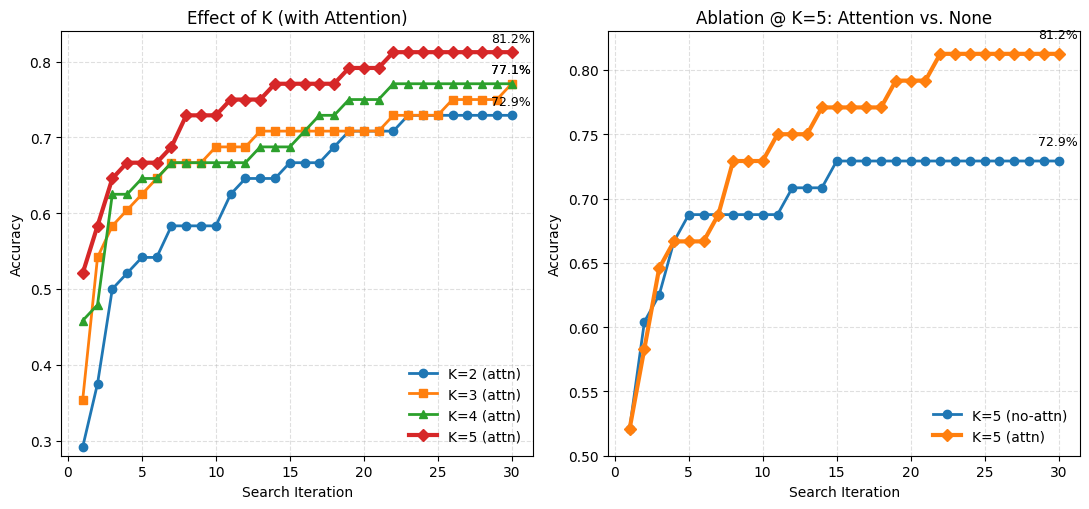

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------ plot ------------------
iters = np.arange(1, len(attn_b5) + 1)

plt.figure(figsize=(11, 5.2))

# (A) Branch width comparison (with attention)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(iters, Attn_b2, marker='o', linewidth=2, label='K=2 (attn)')
ax1.plot(iters, Attn_b3, marker='s', linewidth=2, label='K=3 (attn)')
ax1.plot(iters, Attn_b4, marker='^', linewidth=2, label='K=4 (attn)')
ax1.plot(iters, attn_b5, marker='D', linewidth=3, label='K=5 (attn)')  # highlight

ax1.set_xlabel('Search Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('Effect of K (with Attention)')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_ylim(0.28, 0.84)
ax1.legend(loc='lower right', frameon=False)

# annotate final accuracies
def annotate_final(ax, y, x_pos=0.995):
    ax.annotate(f'{y[-1]*100:.1f}%',
                xy=(iters[-1], y[-1]),
                xytext=(x_pos, y[-1]+0.01),
                textcoords=('axes fraction','data'),
                ha='right', va='bottom', fontsize=9)

for series in [Attn_b2, Attn_b3, Attn_b4, attn_b5]:
    annotate_final(ax1, series)

# (B) Ablation at width=5: attention vs no attention
ax2 = plt.subplot(1, 2, 2)
ax2.plot(iters, no_attn_b5, marker='o', linewidth=2, label='K=5 (no-attn)')
ax2.plot(iters, attn_b5, marker='D', linewidth=3, label='K=5 (attn)')  # highlight

ax2.set_xlabel('Search Iteration')
ax2.set_ylabel('Accuracy')
ax2.set_title('Ablation @ K=5: Attention vs. None')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_ylim(0.50, 0.83)
ax2.legend(loc='lower right', frameon=False)

annotate_final(ax2, no_attn_b5)
annotate_final(ax2, attn_b5)

plt.tight_layout()
plt.savefig("branch_width_ablation.png")
plt.show()

In [26]:
cost = [29047.291666666668, 41739.3125, 53803.854166666664, 63989.416666666664, 73570.85416666666, 83465.77083333333, 92446.83333333333, 101538.875, 110496.29166666667, 118834.27083333334, 126767.95833333334, 134625.14583333334, 142420.3541666667, 149548.43750000003, 156537.3541666667, 162677.37500000003, 171002.43750000003, 179204.4166666667, 187316.95833333334, 194465]

d1 = cost[-1] - cost[-2]
d2 = cost[-2] - cost[-3]
attn_cost = [29047.291666666668, 48336.04166666667, 66039.16666666667, 82402.89583333334, 96098.27083333334, 109859.81250000001, 122946.14583333334, 135268.89583333334, 147597.64583333334, 160021.7291666667, 171667.1666666667, 183288.1041666667, 194623.87500000003, 204979.27083333337, 215720.47916666672, 225512.72916666672, 234814.77083333337, 244894.37500000003, 254323.62500000003, 262808.8125, 271955.1041666667, 280115.8125, 287809.7083333333, 294660.3958333333, 301080.4375, 308925.7916666667, 315811.0833333334, 322853.3333333334, 329793.3541666667, 336380.3333333334]
print(cost[19])
print(attn_cost[19])


cost_no_attn = cost[-1] + 10* (d1+d2)/2
cost_attn = attn_cost[29]

print(cost_no_attn, cost_attn)
increase_ratio = (cost_attn - cost_no_attn) / cost_no_attn
print(increase_ratio)

performance_increase_ratio = (attn_b5[-1] - no_attn_b5[-1]) / no_attn_b5[-1]
print(performance_increase_ratio)


194465
262808.8125
270767.91666666657 336380.3333333334
0.24231976031133734
0.054054054054054
